# Epidemiological Model: Parameter Exploration

In [1]:
# 🟢 Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


# 1. Mathematical equations and simulation runner from the lab

In [2]:
# Define the SIRD differential equations used by every simulation.
def sird_model(y, t, beta, gamma, mu):
    """Return the rates of change for the SIRD compartments."""
    S, I, R, D = y
    N = S + I + R + D

    # Infectious individuals leave I through recovery or disease-related death.
    new_infections = beta * S * I / N
    recoveries = gamma * I
    deaths = mu * I

    dSdt = -new_infections
    dIdt = new_infections - recoveries - deaths
    dRdt = recoveries
    dDdt = deaths

    return dSdt, dIdt, dRdt, dDdt

# A small numerical check confirms that the model returns four compartment rates.
test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("The model returns one rate for S, I, R, and D.")

SIRD test result: (-2.97, 1.87, 1.0, 0.1)
The model returns one rate for S, I, R, and D.


In [ ]:
# 🟡 add a new line in the plot
def run_sird_simulation(beta, gamma, mu, N=1000, I0=10, days=150):

    # TODO: Set up initial conditions with 4 compartments
    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    # Time points (same as before)
    # Note: days - 1 as the endpoint so that t[i] == i exactly
    t = np.linspace(0, days - 1, days)

    # TODO: Solve SIRD equations (adapt from SIR)
    sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
    S, I, R, D = sol.T

    # TODO: Create plot with 4 lines
    plt.figure(figsize=(10, 6))
    plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
    plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
    plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
    plt.plot(t, D, 'k-', label='Deaths', linewidth=2)

    plt.xlabel('Time (days)')
    plt.ylabel('Population')
    plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return t, S, I, R, D

## 2. Part 1: recovery-rate comparison
We compare five recovery rates while holding transmission, mortality, population size, and initial infections constant. For each value, the table records the reproduction number, the maximum number infectious at one time, when that maximum occurs, and cumulative deaths at the end of the simulation.

In [9]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """Summarize epidemic outcomes across a fixed set of recovery rates."""
    gamma_values = [0.05, 0.10, 0.15, 0.20, 0.25]
    records = []

    for gamma in gamma_values:
        t_sird, _, infected, _, deaths = run_sird_simulation(
            beta, gamma, mu, N, I0, simulation_days
        )
        # R0 compares transmission with removal from infection by recovery or death.
        effective_r0 = beta / (gamma + mu)
        peak_index = int(np.argmax(infected))
        records.append({
            'Recovery rate (gamma)': gamma,
            'Basic reproduction number (R0)': effective_r0,
            'Peak infectious (people)': np.max(infected),
            'Peak day': t_sird[peak_index],
            'Total deaths (people)': deaths[-1]
        })

    return pd.DataFrame(records)

### Part 1 results

The formatted table below makes the effect of faster recovery easy to compare across the selected parameter values.

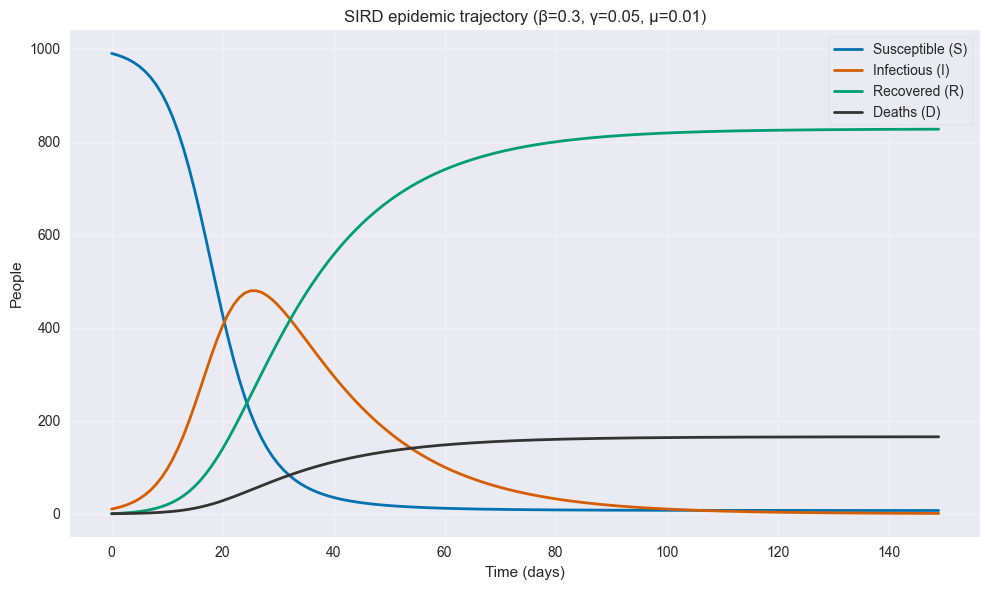

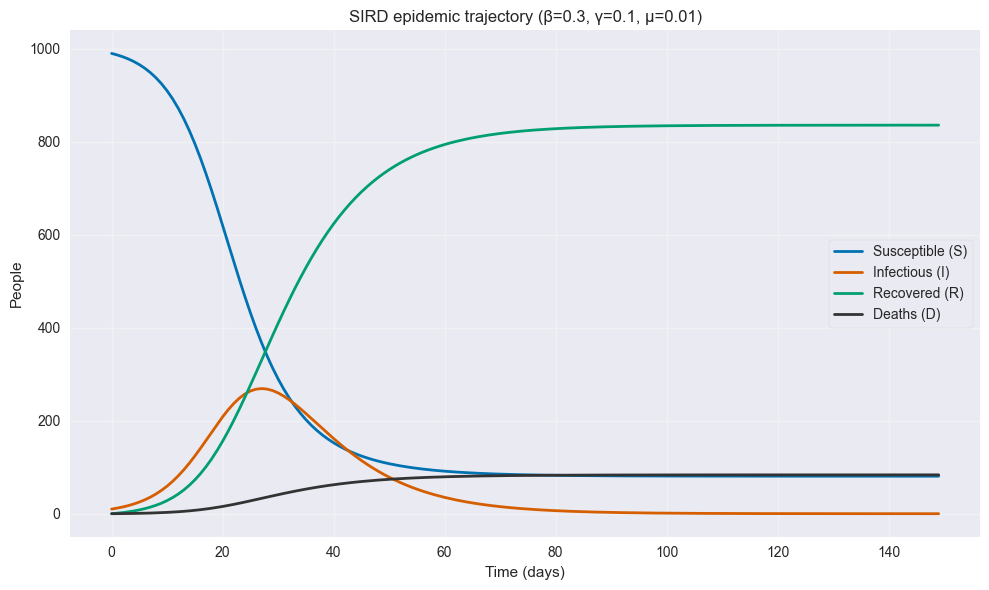

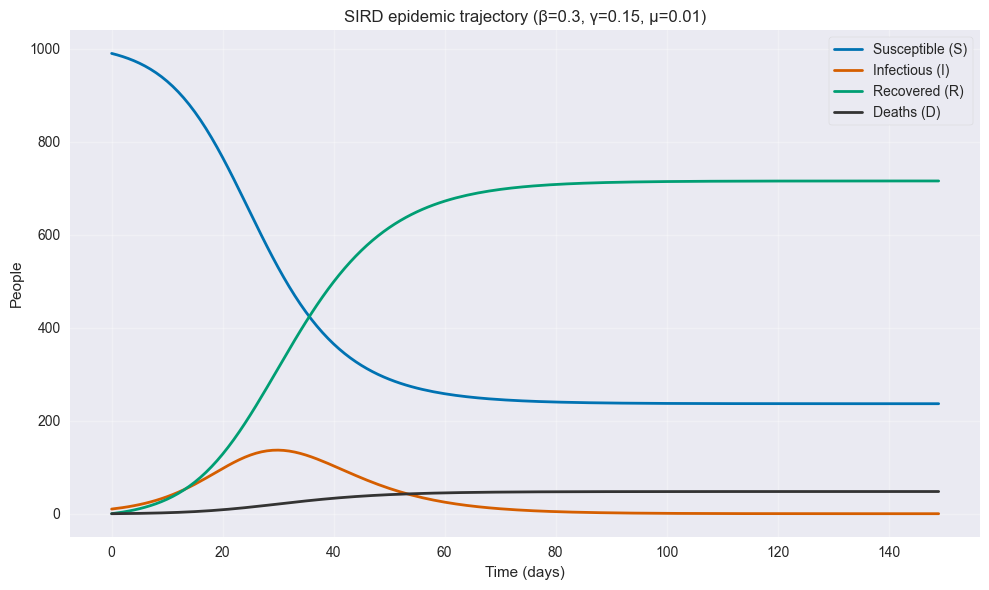

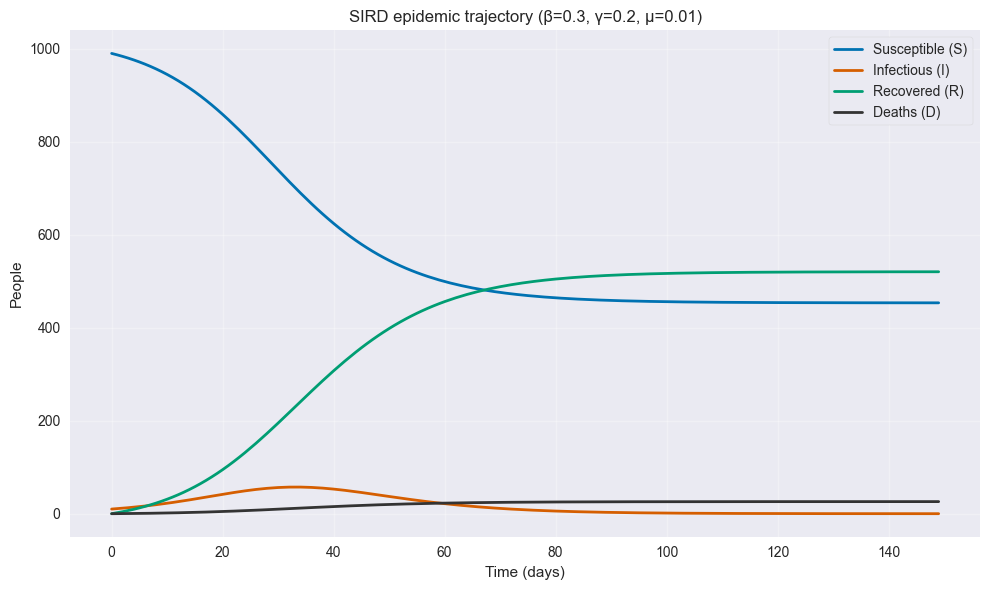

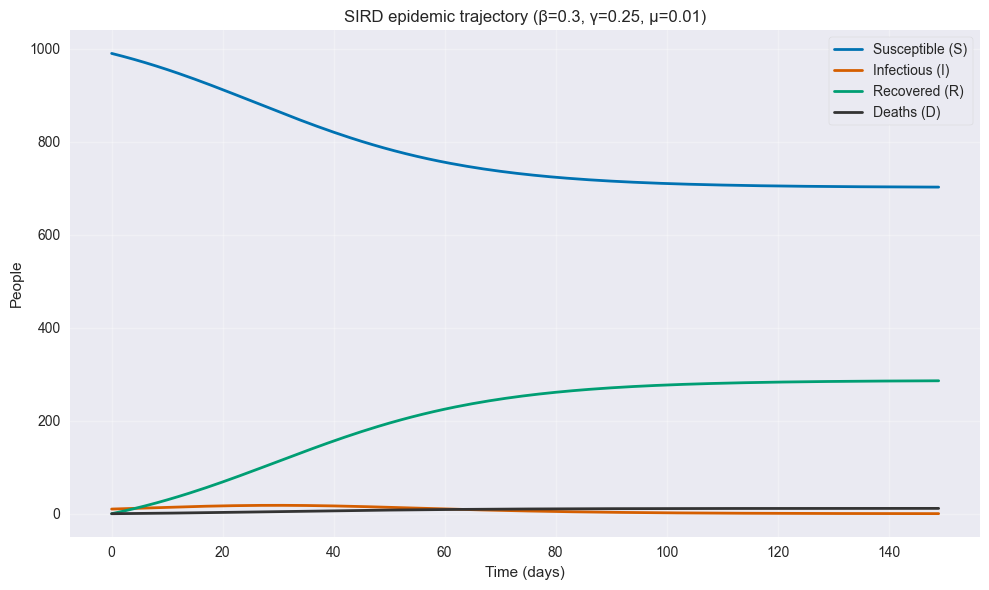

,Recovery rate (gamma),Basic reproduction number (R0),Peak infectious (people),Peak day,Total deaths (people)
0,0.05,5.00,479.7,26,165.4
1,0.10,2.73,269.1,27,83.6
2,0.15,1.88,136.8,30,47.7
3,0.20,1.43,57.4,33,26.0
4,0.25,1.15,18.0,30,11.4


In [10]:
results = analyze_recovery_rates(
    beta=0.3, mu=0.01, N=1000, I0=10, simulation_days=150
)

# Display a compact table with consistent precision for direct comparison.
display(
    results.style
    .format({
        'Recovery rate (gamma)': '{:.2f}',
        'Basic reproduction number (R0)': '{:.2f}',
        'Peak infectious (people)': '{:.1f}',
        'Peak day': '{:.0f}',
        'Total deaths (people)': '{:.1f}'
    })
    .set_caption('Part 1: outcomes by recovery rate')
)

## 3. Part 2: scenario comparison

We compare two 200-day scenarios using the same five recovery rates. Scenario A represents high transmission and mortality; Scenario B represents lower transmission and mortality. The tables and figure below use identical metrics and formatting so the public-health trade-off is easy to inspect.

**Scenario A — High transmission:** $\beta=0.4$, $\mu=0.02$, $N=1000$, $I_0=5$

**Scenario B — Low transmission:** $\beta=0.2$, $\mu=0.005$, $N=1000$, $I_0=5$

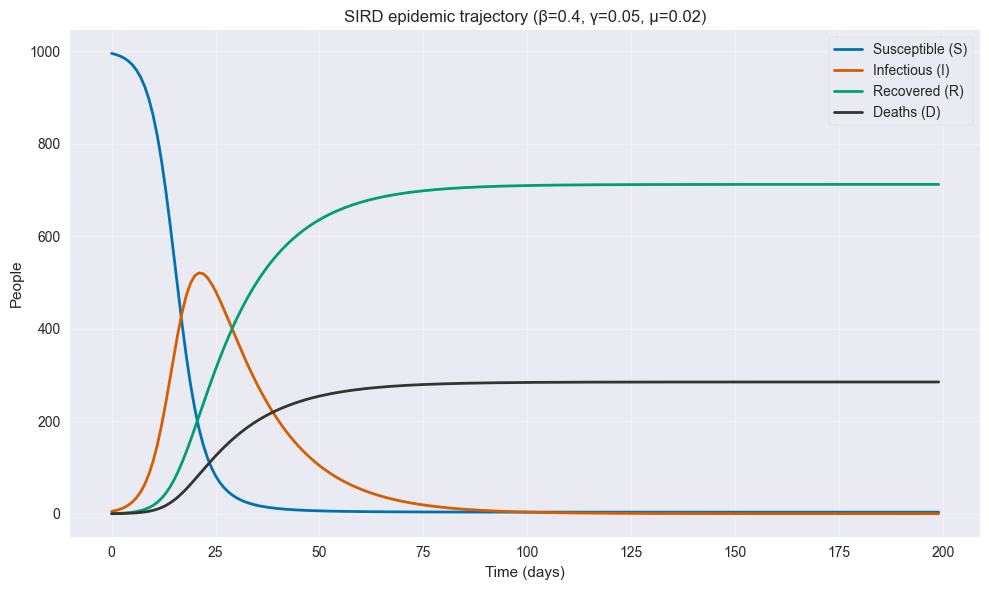

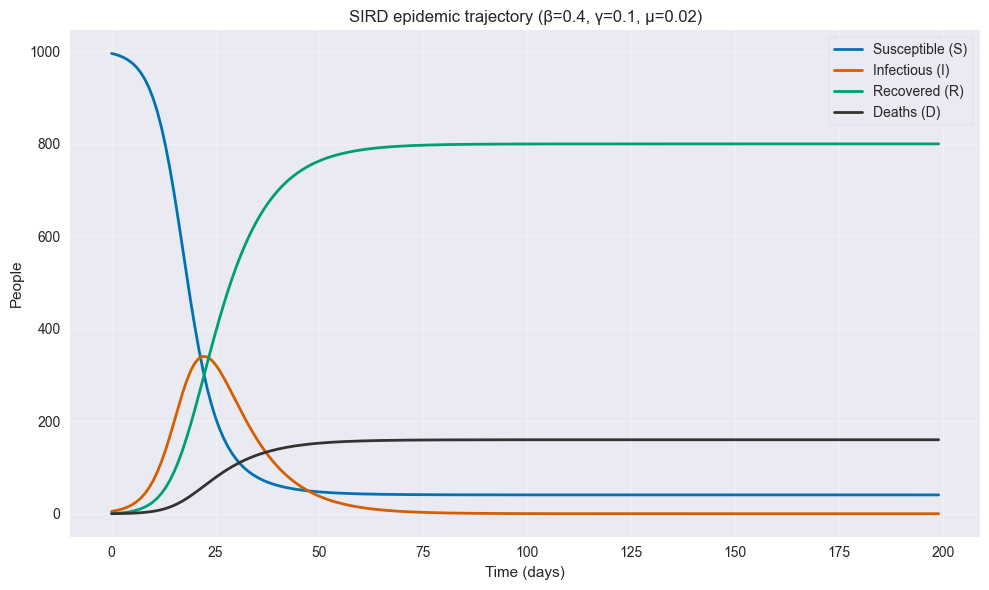

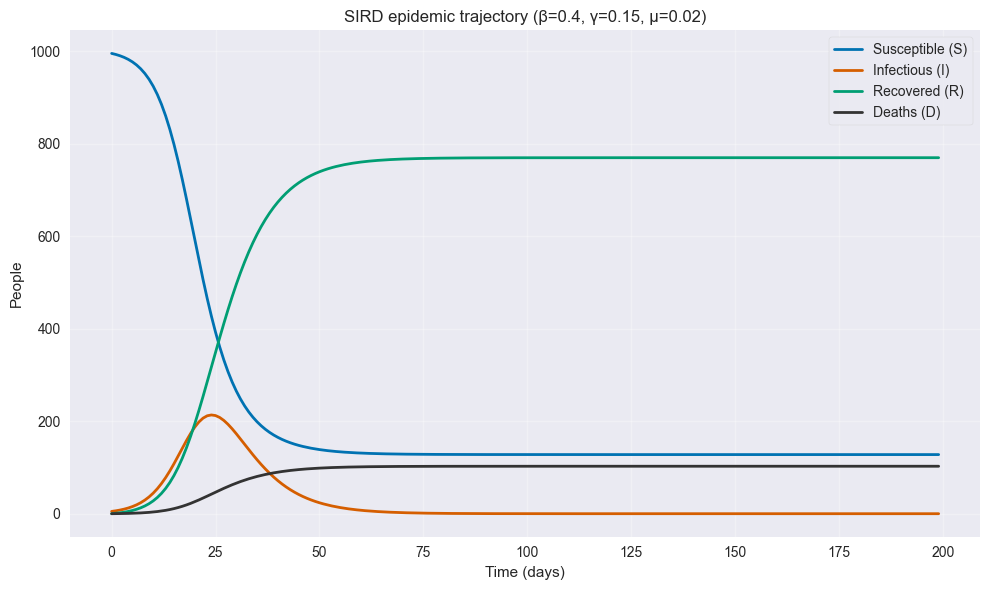

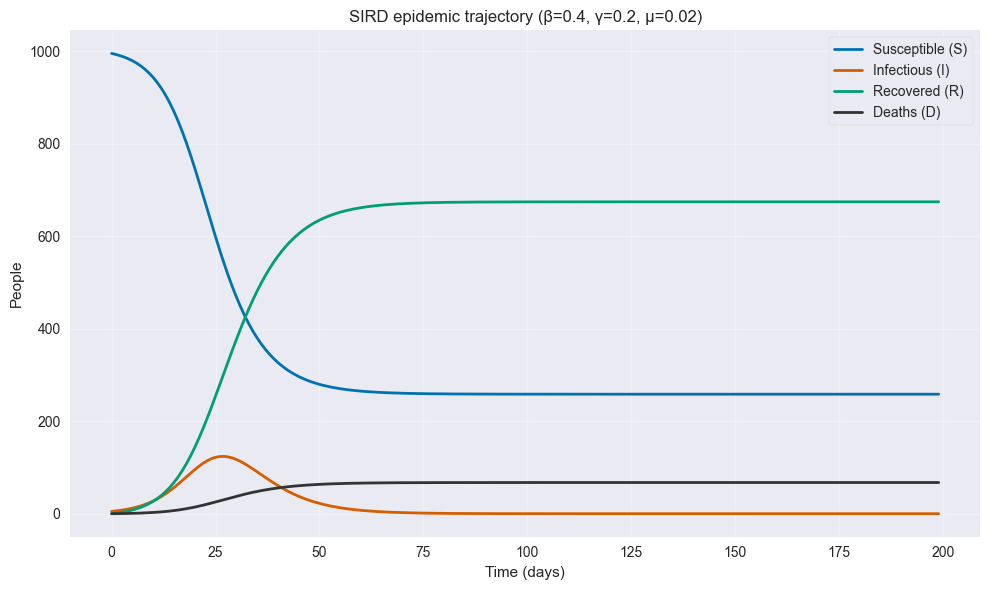

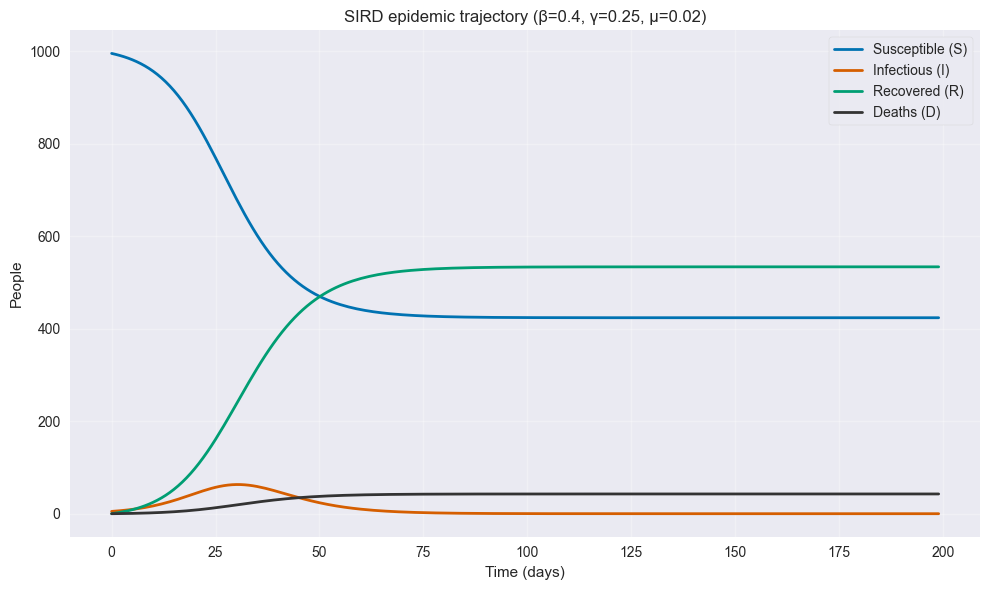

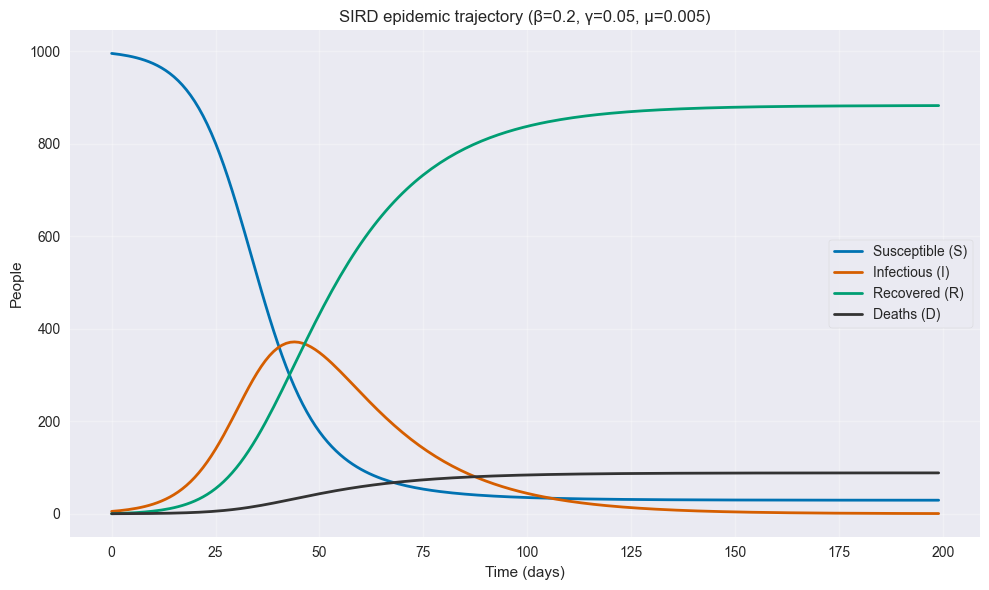

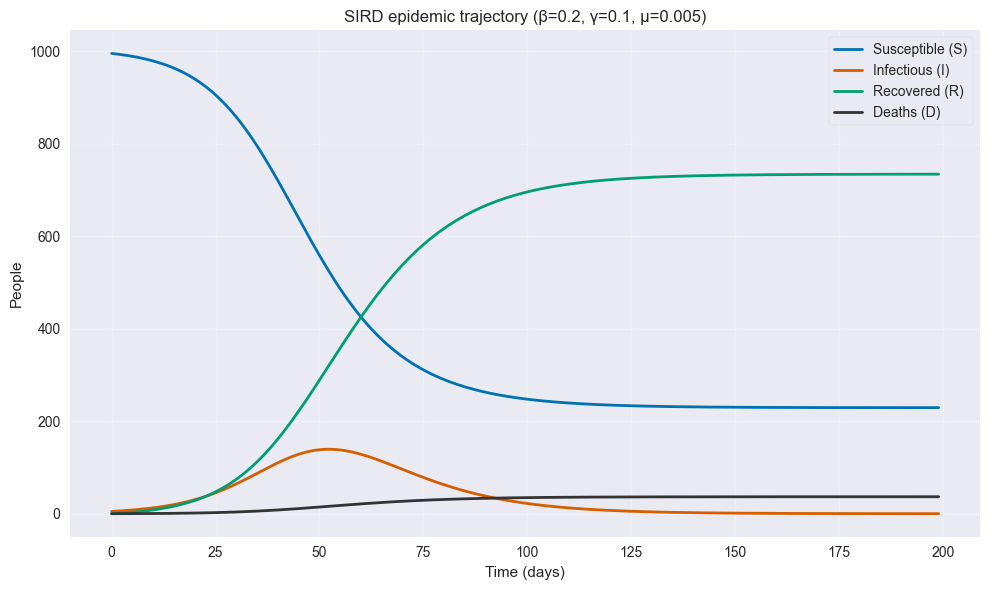

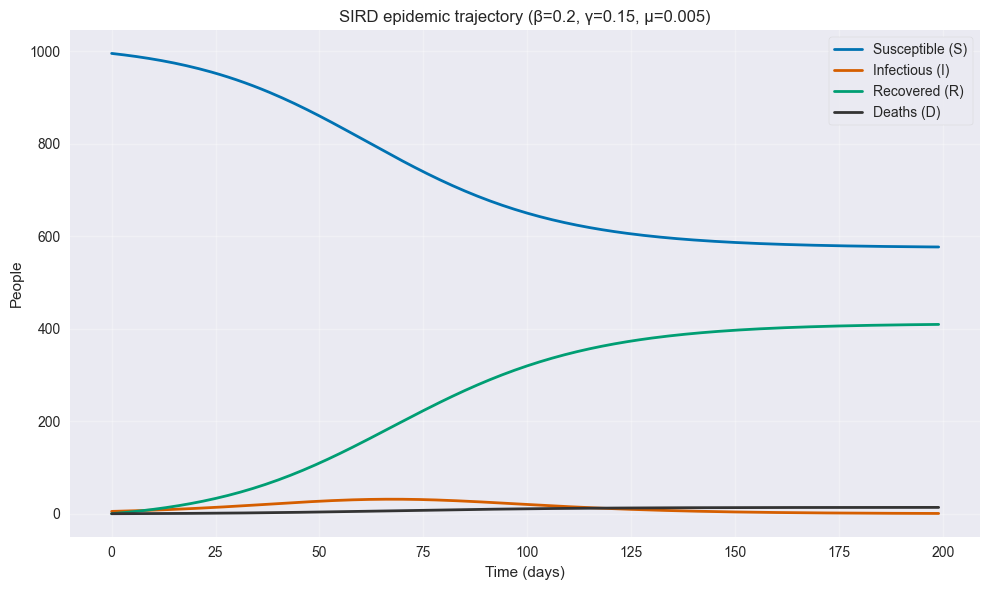

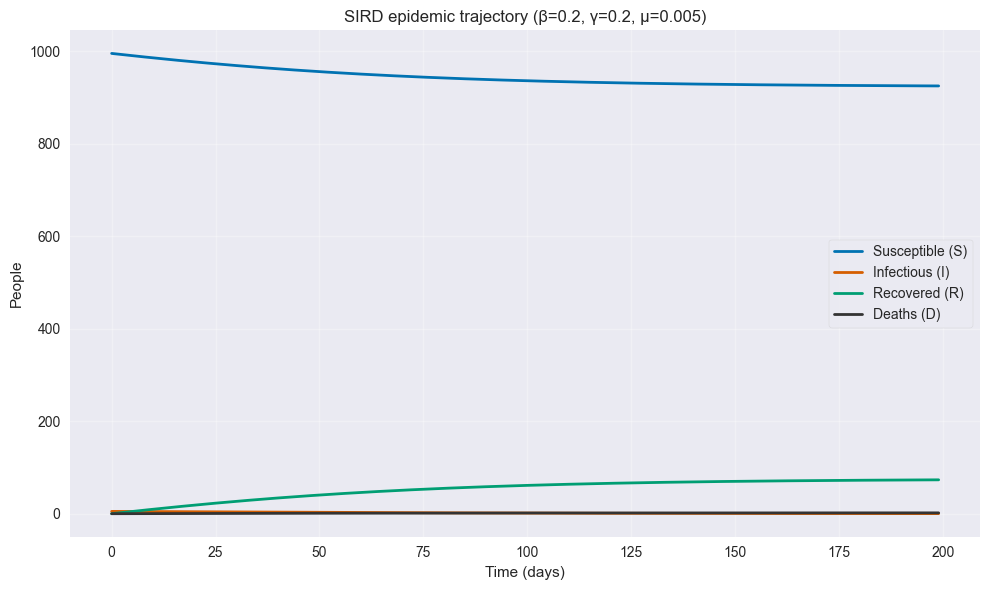

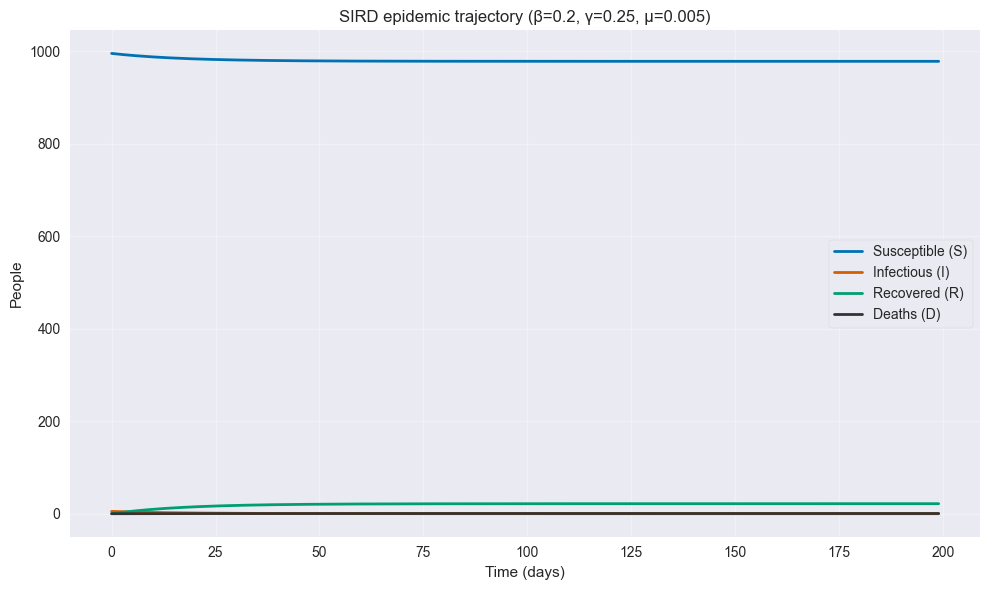

,Scenario,Recovery rate (gamma),Basic reproduction number (R0),Peak infectious (people),Peak day,Total deaths (people)
0,A: High transmission,0.05,5.71,520.6,21,284.8
1,A: High transmission,0.10,3.33,340.1,22,159.9
2,A: High transmission,0.15,2.35,213.5,24,102.6
3,A: High transmission,0.20,1.82,123.9,27,67.4
4,A: High transmission,0.25,1.48,63.1,30,42.7
5,B: Low transmission,0.05,3.64,371.4,44,88.2
6,B: Low transmission,0.10,1.90,139.3,52,36.7
7,B: Low transmission,0.15,1.29,31.3,67,13.6
8,B: Low transmission,0.20,0.98,5.0,0,1.8
9,B: Low transmission,0.25,0.78,5.0,0,0.4


In [11]:
results1 = analyze_recovery_rates(
    beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200
)
results2 = analyze_recovery_rates(
    beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200
)

comparison_columns = [
    'Recovery rate (gamma)', 'Basic reproduction number (R0)',
    'Peak infectious (people)', 'Peak day', 'Total deaths (people)'
]
scenario_a = results1[comparison_columns].copy()
scenario_b = results2[comparison_columns].copy()
scenario_a.insert(0, 'Scenario', 'A: High transmission')
scenario_b.insert(0, 'Scenario', 'B: Low transmission')
scenario_results = pd.concat([scenario_a, scenario_b], ignore_index=True)

display(
    scenario_results.style
    .format({
        'Recovery rate (gamma)': '{:.2f}',
        'Basic reproduction number (R0)': '{:.2f}',
        'Peak infectious (people)': '{:.1f}',
        'Peak day': '{:.0f}',
        'Total deaths (people)': '{:.1f}'
    })
    .set_caption('Part 2: scenario outcomes')
)

### Scenario comparison figure

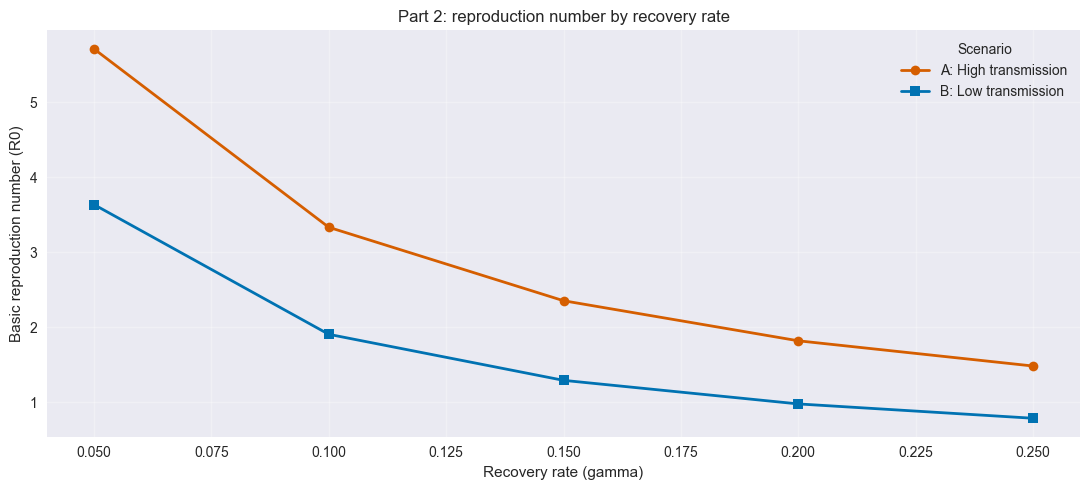

In [12]:
plt.figure(figsize=(11, 5))
plt.plot(
    results1['Recovery rate (gamma)'],
    results1['Basic reproduction number (R0)'],
    marker='o', linewidth=2, label='A: High transmission', color='#D55E00'
)
plt.plot(
    results2['Recovery rate (gamma)'],
    results2['Basic reproduction number (R0)'],
    marker='s', linewidth=2, label='B: Low transmission', color='#0072B2'
)
plt.xlabel('Recovery rate (gamma)')
plt.ylabel('Basic reproduction number (R0)')
plt.title('Part 2: reproduction number by recovery rate')
plt.legend(title='Scenario')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scenario analysation

Scenario 1 is worse, because the R0 is higher compared to scenario 1. For each gamma value the scenario one had more peak infected and multiple times more total deaths. When comparing the peak days, the scenarios 2 peak occurs later with a flatter curve, which is a good thing. Look back to covid and all the campaigns about flatening the curve. This is beneficial because the doctors will have less patients to treat at the same time and that can prevent even more deaths.